# Convolutions, CNNs, and End-to-End Training

This notebook introduces the first family of end-to-end architectures for image reconstruction. We start from the basic convolution operation, explain why CNNs are natural for images, and then show how a simple reconstruction model can be trained when a forward corruptor operator $K$ is known. The goal is to build the first complete bridge between image structure, neural architectures, and synthetic supervised training for inverse problems.


## Convolutions and Padding

Working with images is completely different from working with tabular data, not only because the number of features in images is usually much larger than in tabular data, but also because these features must be treated differently.

Indeed, when we analyze an image, the value of a single pixel **alone** is of limited importance: we mostly care about the behavior of a set of neighbouring pixels which, when taken together, produce a **visible object** in the image. Moreover, we sometimes also care about more **global** information, for example how the object described by a neighbourhood of pixels interacts with other objects, with the environment, and with its relative position inside the image.

More formally, if we define **punctual information** as any information that can be extracted by considering a single pixel isolated from its context, **local information** as any information that can be extracted from a small set of neighbouring pixels, and **global information** as any information that requires knowledge of the entire image, then we can say that image-processing tasks rely mostly on local and global information, with only a very small amount of punctual information.

From this observation, one can note that the classical MLP architecture, defined by a chain of linear transformations alternated with non-linear activation functions, is not a natural choice for images because it processes each pixel as a single, isolated neuron. Instead, it is better to consider a network in which each **linear** layer is replaced by a layer that takes **local** information into account. The simplest mathematical tool that achieves this is the **convolution** operation.

```{image} /imgs/convolution.png
:width: 800px
:align: center
```

As shown in the image above, a convolution is a linear operation involving an input image $x$ with shape $n_x \times n_y$ and a convolution kernel $\mathcal{K}$ with shape $k \times k$, usually much smaller than the image itself. Each pixel at position $(i, j)$ of the output image $y = \mathcal{K} \ast x$ is obtained by centering the kernel on pixel $(i, j)$ of the input image, multiplying the kernel element-wise by the corresponding input pixels, and summing the result. In formula:

$$
y_{i, j} = \sum_{t= -\frac{k}{2}}^{\frac{k}{2}} \sum_{l = -\frac{k}{2}}^{\frac{k}{2}} \mathcal{K}_{t, l} x_{i - t, j - l}.
$$

As a result, each pixel of the output image $y$ is influenced by a $k \times k$ neighbourhood of the input image $x$, enforcing the required locality of the operation.

```{note}
Sometimes the convolution kernel is considered to be applied from the upper-left corner instead of being centered. While this makes no difference in practice, it can slightly modify the formula.
```

One key limitation of convolutions, clearly visible in the image above, is that the output image has a much smaller size than the corresponding input. This makes plain convolutions impractical for end-to-end image reconstruction tasks, since we usually expect the output shape to match the input shape.

To overcome this limitation, a common technique is **padding**, or **padded convolution**. The idea is to pad the input image with a suitable number of zeros before applying the convolution, so that the output shape is preserved after the kernel is applied. In practice, if the kernel has shape $k \times k$, one should pad the input with $\frac{k-1}{2}$ zeros on each side to preserve the image shape.
The result of a padded convolution is shown in the image below.

```{image} /imgs/padded-convolution.png
:width: 800px
:align: center
```

In the following, we will always consider padded convolution when working with images.


## Convolutional Neural Networks (CNN)

By exploiting the observation above, we can design a neural network architecture for working with images. Its simplest version, called a **Convolutional Neural Network (CNN)**, is obtained by taking a classical Multi-layer Perceptron (i.e. the simplest neural-network architecture described in the previous chapter of this course) and replacing the `Linear` layer with a `Conv2d` layer. The **parameters** of a CNN are the numbers contained in the convolution kernels, which determine how the pixels are processed.

In general, each convolutional layer is composed of a large pre-determined set of convolution kernels with the same shape, each processing the same image in parallel and extracting different information from it. A common practice is then to stack multiple convolutional layers one after another, alternating them with non-linear activation functions such as **ReLU**.

```{note}
A common practice, justified by information theory, suggests that the number of convolutional kernels should increase as we go deeper in the network.
```

Let us see how to implement such a neural-network architecture in PyTorch.


In [7]:
import torch
from torch import nn

class SimpleCNN(nn.Module):
    def __init__(self, in_ch, out_ch, n_filters, kernel_size=3):
        super().__init__()

        # Define (convolution) layers -> NOTE: padding="same" means "padded convolution"
        self.conv1 = nn.Conv2d(in_channels=in_ch, out_channels=n_filters, kernel_size=kernel_size, padding="same")
        self.conv2 = nn.Conv2d(in_channels=n_filters, out_channels=n_filters, kernel_size=kernel_size, padding="same")
        self.conv3 = nn.Conv2d(in_channels=n_filters, out_channels=out_ch, kernel_size=kernel_size, padding="same")

        self.relu = nn.ReLU()

    def forward(self, x):
        h = self.relu(self.conv1(x))
        h = self.relu(self.conv2(h))
        out = self.conv3(h)
        return out

The code above shows how to create a very simple Convolutional Neural Network with three convolutional layers, each with a given number of filters and a kernel size of 3. Using a small kernel size (such as 3 or 5) is common practice, since it keeps the model efficient while keeping the total number of parameters relatively small.

This model can be trained using exactly the same loop as in the previous chapter, with the only difference that, since it is not an `IPPy` model, its weights need to be saved via the following command:

```
torch.save(model.state_dict(), PATH-TO-SAVE.pth)
```

and loaded via:

```
model.load_state_dict(torch.load(PATH-TO-SAVE.pth, weights_only=True))
```


### Training End-to-End Models from Synthetic Measurements

Once a dataset of clean images $\{x_i\}_{i=1}^N$ and an explicit linear corruptor operator $K$ are available, it is straightforward to build an end-to-end training pipeline for inverse problems. The main idea is to generate the corrupted measurements **at training time** instead of storing them in advance. For each clean image $x_i$, we synthesize a datum

$$
y_i^\delta = Kx_i + e,
$$

where $e$ denotes a noise realization, for example Gaussian noise. We can then train a neural network $f_\Theta$ by minimizing a standard supervised loss between the reconstruction and the clean target:

$$
\min_\Theta \frac{1}{N} \sum_{i=1}^N \| f_\Theta(y_i^\delta) - x_i \|_2^2.
$$

From a practical point of view, this means that the dataset only needs to contain the clean images. The measurement model is generated automatically during training by applying the known operator $K$ and by adding noise. In this chapter we use the simple `SimpleCNN` model introduced above, but the same procedure applies to essentially any end-to-end architecture.

```{note}
Adding noise during training is crucial if one wants to avoid the **inverse crime**. We will discuss this issue more carefully later in the course, but for now it is important to remember that training on perfectly noiseless synthetic data usually leads to unrealistic performance estimates.
```

Let us implement this idea on the Mayo dataset by using a Motion Blur operator from `IPPy` and by training `SimpleCNN` with the MSE loss.


In [8]:
import glob
import importlib.util
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

here = Path.cwd().resolve()
for base in (here, *here.parents):
    if (base / 'weights').exists() and (base / 'Mayo').exists():
        book_root = base
        break
else:
    raise FileNotFoundError('Could not locate the course root containing Mayo and weights.')

for base in (here, *here.parents):
    if (base / 'IPPy').exists():
        ippy_root = base / 'IPPy'
        break
else:
    raise FileNotFoundError('Could not locate the local IPPy package.')

operators_spec = importlib.util.spec_from_file_location('course_ippy_operators', ippy_root / 'operators.py')
operators = importlib.util.module_from_spec(operators_spec)
operators_spec.loader.exec_module(operators)

weights_dir = book_root / 'weights'
weights_dir.mkdir(exist_ok=True)

def get_device():
    if torch.cuda.is_available():
        return 'cuda'
    try:
        if torch.backends.mps.is_available():
            return 'mps'
    except AttributeError:
        pass
    return 'cpu'

def gaussian_noise(y, noise_level):
    e = torch.randn_like(y, device=y.device)
    return e / torch.norm(e) * torch.norm(y) * noise_level

class MayoDataset(Dataset):
    def __init__(self, data_path, data_shape):
        super().__init__()
        self.data_path = data_path
        self.data_shape = data_shape
        self.fname_list = glob.glob(f'{data_path}/*/*.png')

    def __len__(self):
        return len(self.fname_list)

    def __getitem__(self, idx):
        img_path = self.fname_list[idx]
        x = Image.open(img_path).convert('L')
        x = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize(self.data_shape),
        ])(x)
        return x

device = get_device()
train_dataset = MayoDataset(data_path=str(book_root / 'Mayo' / 'train'), data_shape=256)
test_dataset = MayoDataset(data_path=str(book_root / 'Mayo' / 'test'), data_shape=256)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

K = operators.Blurring(
    img_shape=(256, 256),
    kernel_type='motion',
    kernel_size=9,
    motion_angle=20,
)

print('Device:', device)
print('Training images:', len(train_dataset))
print('Test images:', len(test_dataset))
print('Weights directory:', weights_dir)


Device: cpu
Training images: 3306
Test images: 327
Weights directory: C:\Users\tivog\computational-imaging\years\2025-26\weights


The training loop is extremely simple. At each iteration we:

1. load a clean batch $x$ from the Mayo dataset;
2. generate the corresponding blurred and noisy measurements $y^\delta = Kx + e$;
3. feed $y^\delta$ to the network;
4. compare the output with the clean batch $x$ through the `MSELoss`;
5. update the parameters with backpropagation.

This is the standard supervised training mechanism for synthetic inverse problems: the network sees corrupted data as input and clean images as targets, while the corruptions are generated online from the known forward model.


Epoch 1/30: 100%|██████████| 414/414 [02:54<00:00,  2.38it/s, avg_loss=0.002511, batch_loss=0.000971]


Epoch 1: training loss = 0.002511


Epoch 2/30: 100%|██████████| 414/414 [02:51<00:00,  2.42it/s, avg_loss=0.000804, batch_loss=0.000627]


Epoch 2: training loss = 0.000804


Epoch 3/30: 100%|██████████| 414/414 [02:51<00:00,  2.42it/s, avg_loss=0.000614, batch_loss=0.000664]


...

Epoch 28: training loss = 0.000349


Epoch 29/30: 100%|██████████| 414/414 [02:49<00:00,  2.44it/s, avg_loss=0.000347, batch_loss=0.000360]


Epoch 29: training loss = 0.000347


Epoch 30/30: 100%|██████████| 414/414 [02:49<00:00,  2.44it/s, avg_loss=0.000342, batch_loss=0.000270]


Epoch 30: training loss = 0.000342
Saved SimpleCNN weights to: C:\Users\tivog\computational-imaging\years\2025-26\weights\CNN.pth


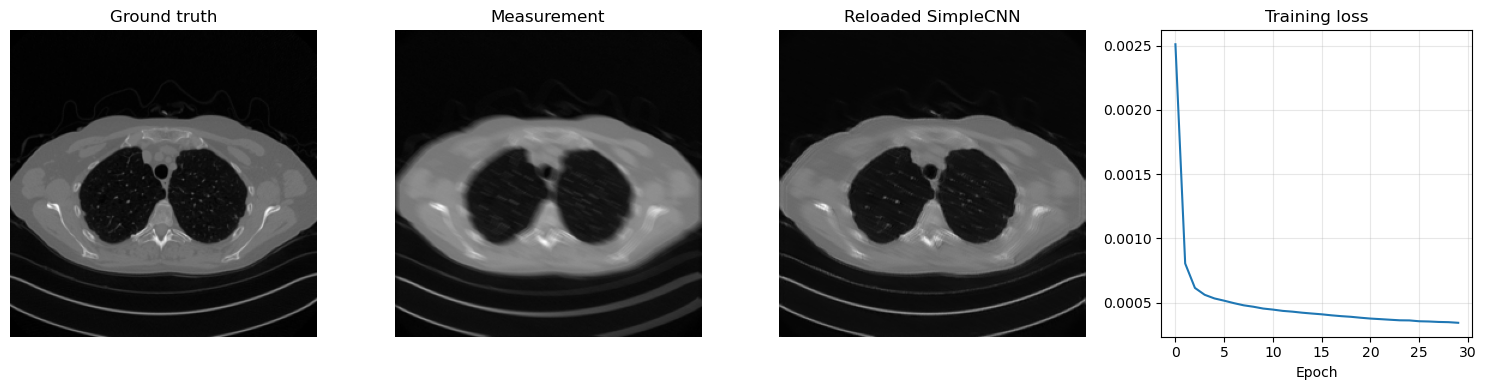

In [9]:
from tqdm.auto import tqdm

torch.manual_seed(0)

model = SimpleCNN(in_ch=1, out_ch=1, n_filters=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

num_epochs = 30
noise_level = 0.01
history = []
weights_path = weights_dir / 'CNN.pth'

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs}', leave=True)
    for step, x_batch in enumerate(progress_bar, start=1):
        x_batch = x_batch.to(device)

        with torch.no_grad():
            y_batch = K(x_batch)
            y_batch = y_batch + gaussian_noise(y_batch, noise_level=noise_level)

        prediction = model(y_batch)
        loss = loss_fn(prediction, x_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix(batch_loss=f'{loss.item():.6f}', avg_loss=f'{epoch_loss / step:.6f}')

    history.append(epoch_loss / len(train_loader))
    print(f'Epoch {epoch + 1}: training loss = {history[-1]:.6f}')

torch.save(model.state_dict(), weights_path)
print(f'Saved SimpleCNN weights to: {weights_path}')

reloaded_model = SimpleCNN(in_ch=1, out_ch=1, n_filters=32)
reloaded_model.load_state_dict(torch.load(weights_path, map_location='cpu', weights_only=True))
reloaded_model = reloaded_model.to(device)
reloaded_model.eval()

with torch.no_grad():
    x_test = next(iter(test_loader))[0:1].to(device)
    y_test = K(x_test)
    y_test = y_test + gaussian_noise(y_test, noise_level=noise_level)
    x_pred = reloaded_model(y_test)

plt.figure(figsize=(15, 4))
plt.subplot(1, 4, 1)
plt.imshow(x_test.cpu().squeeze(), cmap='gray')
plt.title('Ground truth')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(y_test.cpu().squeeze(), cmap='gray')
plt.title('Measurement')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(x_pred.cpu().squeeze(), cmap='gray')
plt.title('Reloaded SimpleCNN')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.plot(history)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


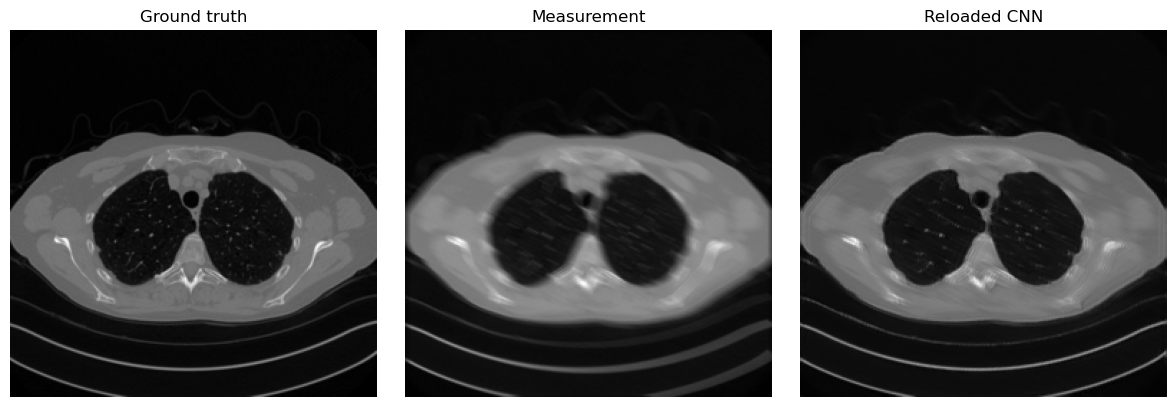

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

# Reload the saved CNN weights and test them on one image.
model = SimpleCNN(in_ch=1, out_ch=1, n_filters=32, kernel_size=3)
model.load_state_dict(torch.load(weights_dir / 'CNN.pth', weights_only=True, map_location='cpu'))
model = model.to(device)
model.eval()

x_true = test_dataset[0].unsqueeze(0).to(device)
with torch.no_grad():
    y_delta = K(x_true)
    y_delta = y_delta + gaussian_noise(y_delta, noise_level=0.01)
    x_rec = model(y_delta)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(x_true.cpu().squeeze(), cmap='gray')
plt.title('Ground truth')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(y_delta.cpu().squeeze(), cmap='gray')
plt.title('Measurement')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(x_rec.cpu().squeeze(), cmap='gray')
plt.title('Reloaded CNN')
plt.axis('off')

plt.tight_layout()
plt.show()


Given a trained CNN, we can also investigate, for example, the operations learned by the first convolutional layer:


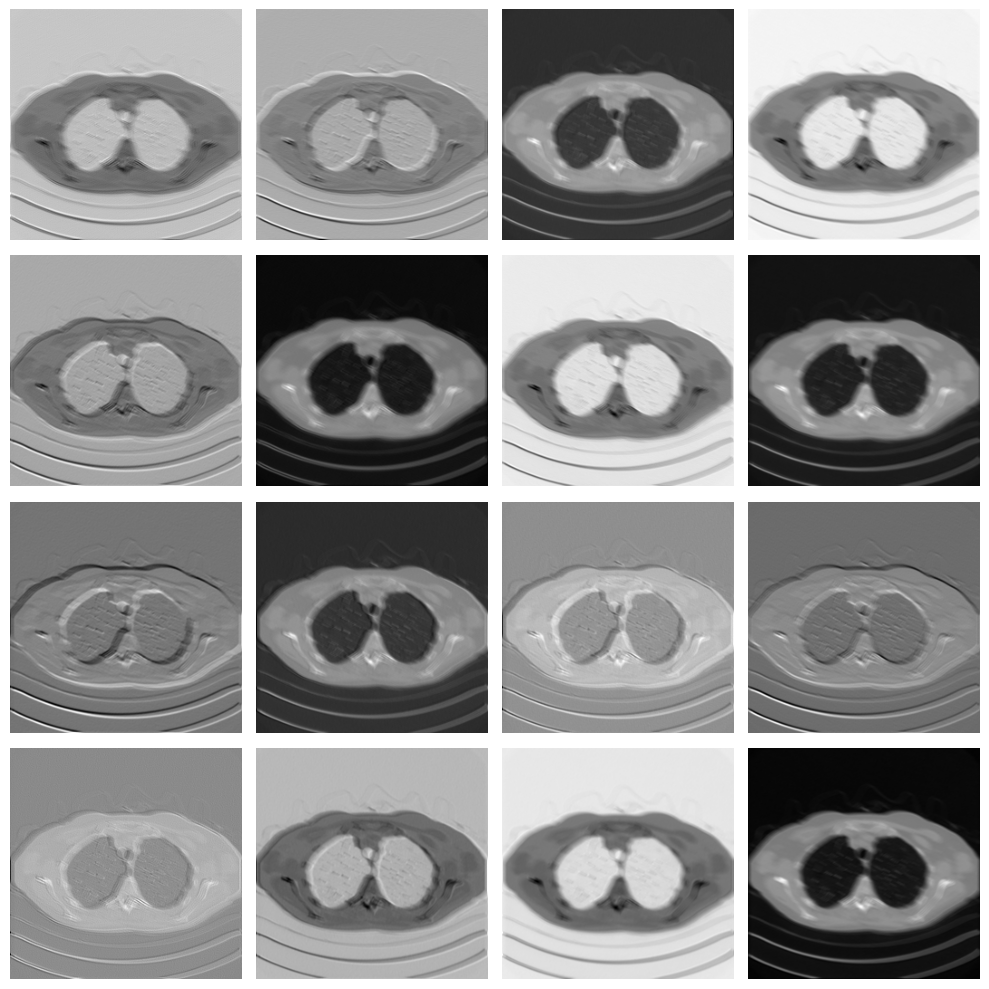

In [12]:
# Variable to store the output
activation = {}

def get_activation(name):
    def hook(model, input, output):
        activation[name] = output.detach()
    return hook

# Register the hook
model.conv1.register_forward_hook(get_activation('conv1'))

# Process image
x_rec = model(y_delta.to(device))

# Get the conv1 activation
conv1_output = activation['conv1']  # Shape: [1, 64, 256, 256]

# Plot all channels
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(conv1_output[0, i].cpu(), cmap='gray')
    ax.axis('off')
plt.tight_layout()
plt.show()

As you can see, each filter in the convolutional layer highlights a particular pattern in the input image, and these features are then processed again by the following convolutional layer to solve the image-reconstruction task.

Note that the visual quality of the resulting image is not as good as, for example, the UNet prediction from the previous chapter. This happens mostly because the model is too small and has too few parameters. To compute the number of parameters of the model in PyTorch, we can do the following:


In [13]:
# Get number of parameters
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {num_params}")

Total trainable parameters: 9857


### Translation Equivariance

So, CNNs are a great alternative to MLPs because they process data based on local information instead of punctual information, which better matches our intuition about how images should be treated. However, is that the whole story? Are there other properties of Convolutional Neural Networks that make them favorable for end-to-end image-reconstruction tasks? The answer is clearly yes.

Arguably the most important of those properties is **translation equivariance**. Formally, a function $f_\Theta$ is said to be translation equivariant if for any vector $v$, it holds:

$$
f_\Theta(x + v) = f_\Theta(x) + v.
$$

Intuitively, it means that the output of the model is **independent** of the position of an object in the image. For example, a bird in the upper-left part of the image is treated in exactly the same way as the same bird in the lower-right part. This property, which is inherited from the properties of convolutions together with the fact that activation functions are applied element-wise, closely follows the classical intuition behind vision. This helps explain why convolutions are such a powerful tool for image-reconstruction tasks, and why these models have been so successful.


### Final activation function

While we have already observed that the default choice for most activation functions is ReLU or a variant of ReLU, particular care should be taken when choosing the activation function for the last layer.

Up to this point, we have always considered neural-network models with **no final activation**, i.e. models in which the last operation is linear (or convolutional). This leads to a model that can generate output values anywhere in the range from $- \infty$ to $+ \infty$. However, we can also consider other activation functions that may be more suitable for image-processing tasks, each with its own pros and cons:

* **ReLU:** Using ReLU as the final activation looks promising: since we already know that each standardized image should lie in the $[0, 1]$ range, enforcing non-negative pixels seems natural. Indeed, when ReLU is used as the final activation, the reconstructed image often looks better, particularly in the background, where it becomes easier for the model to generate a perfectly black region. However, ReLU has the drawback of being non-differentiable at $0$, which is exactly the value we would like to reach in the background and can therefore cause training instabilities.
* **Sigmoid:** From the perspective of the range, sigmoid seems even more promising, since its range is $(0, 1)$, which is almost the same as the range of a standardized image tensor. While this choice guarantees that the reconstruction lies in the correct domain, training with this final activation is usually rather unstable. This is because sigmoid **approaches** $0$ and $1$ at $-\infty$ and $+\infty$, respectively. Therefore, when trying to match the value $0$ in the background, the optimizer tends to push the weights toward infinity, causing instability.
* **Tanh:** Tanh is the most common activation function when working with Residual CNNs (which we will introduce later) because its range is $(-1, 1)$, making it well suited for learning an approximation of the residual mapping. When used on a non-residual CNN, however, this final activation suffers from instability issues similar to those of sigmoid.

To conclude this section, the general recommendation is to use either ReLU or no final activation for standard CNNs, while using Tanh for Residual CNNs. The choice between ReLU and no activation depends on the specific task and usually needs to be tested case by case.


## Exercises

1. Explain why padding is necessary if one wants a convolutional network to produce an output with the same spatial size as the input.
2. In your own words, explain why CNNs are more appropriate than MLPs for image reconstruction tasks.
3. In the training setup based on the operator $K$, what is the role of the noise term $e$ and why is it useful to generate it during training?
4. Compare the possible final activations discussed in this notebook. In which situation is Tanh particularly natural?
5. Code exercise: change the number of filters in `SimpleCNN` and compare both the total number of parameters and the quality of the reconstruction.
6. Code exercise: modify the kernel size of the convolutional layers and observe how the behavior of the model changes.


## Further Reading

For the classical foundations of convolutional neural networks, see {cite}`lecun1998gradient`. For a practical computational reference on PyTorch and training mechanics, see {cite}`paszke2019pytorch` and {cite}`stevens2020deep`. For a broader imaging perspective on learned reconstruction maps and supervised training in inverse problems, see {cite}`ongie2020deep`.
